# **Exploratory Data Analysis of the Global Mental Health Dataset**

This project explores a comprehensive mental health dataset using Python for data cleaning, clinical validation, and multivariate exploratory data analysis. Key steps include handling missing values, removing duplicates, standardizing timestamps, and visualizing complex "flow" relationships between family history, stress levels, and treatment-seeking behavior.

**Tools**: Python, Pandas, Numpy, Matplotlib, Seaborn, Plotly.

**Skills**: Data Cleaning, Clinical Data Validation, Multivariate EDA, Interactive Visualization.

**Author**: Ruth Gezahegn, Medical Student.

**Date**: March, 2026

**Dataset**: Global Mental Health Survey Dataset

#### **Objective**

The objective of this project is to perform a clinically-focused exploratory data analysis (EDA) in order to:

•
**Clean and Validate**: Ensure data integrity by handling null values, duplicates, and identifying clinical anomalies (e.g., "flat-lining" responses).

•
**Understand Distributions**: Analyze the prevalence of mental health indicators across different occupations, genders, and countries.

•
**Explore Multivariate Relationships**: Map the "patient journey" from history and stress to coping mechanisms and final treatment outcomes.

•
**Identify Clinical Gaps**: Detect sub-populations experiencing high stress who are not currently accessing mental health care.

This analysis focuses on clinical relevance, data integrity, and pattern recognition rather than predictive model building.

#### **Dataset Description**

The Global Mental Health dataset contains self-reported medical, demographic, and behavioral information from individuals worldwide. It captures the interplay between workplace environments, personal history, and psychological well-being.

**Important Clarifications**:

•
**Growing_Stress**: A self-reported measure of increasing psychological pressure (Yes, No, Maybe).

•
**Treatment**: A binary outcome indicating whether the individual is currently seeking professional mental health care.

•
**Clinical_Profile**: A derived feature stratifying respondents into 'New Seekers', 'Chronic Seekers', and 'Non-Seekers' based on their history and treatment status.

•
**Timestamp**: Standardized to datetime format to ensure logical temporal consistency.


# **PHASE 1 — DATA LOADING & INITIAL INSPECTION**

### **Step 1: Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

### **step 2: Load the Dataset**

In [2]:
import os
os.listdir('/kaggle/input')

['datasets']

In [3]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ruthgezahegn/mental-health-dataset/Mental Health Dataset.csv


In [4]:
df = pd.read_csv('/kaggle/input/datasets/ruthgezahegn/mental-health-dataset/Mental Health Dataset.csv')

### **Step 3: Basic Structure Check**

In [5]:
df.shape

(292364, 17)

This tells us:

* Number of rows - 292364
* Number of columns - 17


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

This tells us:
* Data types
* Non-null count

In [7]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,2014-08-27 11:29:31,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,2014-08-27 11:31:50,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,2014-08-27 11:32:39,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,2014-08-27 11:37:59,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,2014-08-27 11:43:36,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


To see the first 5 rows.

In [8]:
df.describe()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,734,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,2014-08-27 12:31:41,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,780,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


Numeric summary.

In [9]:
df.describe(include='object')

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,734,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,2014-08-27 12:31:41,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,780,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


Categorical summary.


# **Phase 2: DATA CLEANING**
### **Step 1: Check Missing Values**


In [10]:
df.isna().sum()

Timestamp                     0
Gender                        0
Country                       0
Occupation                    0
self_employed              5202
family_history                0
treatment                     0
Days_Indoors                  0
Growing_Stress                0
Changes_Habits                0
Mental_Health_History         0
Mood_Swings                   0
Coping_Struggles              0
Work_Interest                 0
Social_Weakness               0
mental_health_interview       0
care_options                  0
dtype: int64

This step identifies missing values across all columns. Missing data can affect analysis accuracy and must be handled appropriately.
The self_employed column contained missing values. This will be handled on the next step.

### **Step 2:Handle Missing Values**

In [11]:
df['self_employed'] = df['self_employed'].fillna('Unknown')

In [12]:
df.isna().sum()

Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64

The missing values in self employed were replaced with 'Unknown' to preserve dataset size and avoid introducing bias.

### **Step 3: Check for Duplicate Rows**

In [13]:
df.duplicated().sum()

np.int64(363)

This steps identified 363 duplicated rows. Duplicate rows can distort analysis and therefore should be removed from the data.

In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

After the duplicated rows were dropped there are now zero duplicated rows.

### **Step 4: Convert Data Types**

In [16]:
pd.api.types.is_datetime64_any_dtype(df['Timestamp'])

False

In [17]:
df['Timestamp'].dtype

dtype('O')

The format of the Timestamp column is text/string (not yet recognized as date). It should be changed in to a datetime format.

In [18]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [19]:
df['Timestamp'].dtype

dtype('<M8[ns]')

Now that the Timestamp column was converted to datetime format it enables time-based analysis.

### **Step 5: Verify Cleaning Results**

In [20]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 292001 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   Timestamp                292001 non-null  datetime64[ns]
 1   Gender                   292001 non-null  object        
 2   Country                  292001 non-null  object        
 3   Occupation               292001 non-null  object        
 4   self_employed            292001 non-null  object        
 5   family_history           292001 non-null  object        
 6   treatment                292001 non-null  object        
 7   Days_Indoors             292001 non-null  object        
 8   Growing_Stress           292001 non-null  object        
 9   Changes_Habits           292001 non-null  object        
 10  Mental_Health_History    292001 non-null  object        
 11  Mood_Swings              292001 non-null  object        
 12  Coping_Struggles     

Timestamp                  0
Gender                     0
Country                    0
Occupation                 0
self_employed              0
family_history             0
treatment                  0
Days_Indoors               0
Growing_Stress             0
Changes_Habits             0
Mental_Health_History      0
Mood_Swings                0
Coping_Struggles           0
Work_Interest              0
Social_Weakness            0
mental_health_interview    0
care_options               0
dtype: int64

Dataset was verified after cleaning to ensure completeness and correctness.

# **Phase 3: Exploratory Data Analysis (EDA)**

In this section we explore patterns within the dataset using data visualization and descriptive statistics.

The goal of this analysis is to understand how different factors such as gender, family history, stress levels, and lifestyle behaviors relate to mental health outcomes.

Visualization helps reveal relationships and trends that may not be immediately visible from raw data.

In [21]:
sns.set_palette("crest")

plt.rcParams['figure.figsize'] = (10,6)

### **Step 1: Understanding Key Variables**

In [22]:
df['Gender'].value_counts().to_frame(name='Count')

,Count
Gender,
Male,239850
Female,52151


In [23]:
df['treatment'].value_counts().to_frame(name='Count')

,Count
treatment,
Yes,147354
No,144647


In [24]:
df['family_history'].value_counts().to_frame(name='Count')

,Count
family_history,
No,176688
Yes,115313


In [25]:
df['Growing_Stress'].value_counts().to_frame(name='Count')

,Count
Growing_Stress,
Maybe,99985
Yes,99411
No,92605


In [26]:
df['Occupation'].value_counts().to_frame(name='Count')

,Count
Occupation,
Housewife,66351
Student,61673
Corporate,61108
Others,52720
Business,50149


In [27]:
df['Mood_Swings'].value_counts().to_frame(name='Count')

,Count
Mood_Swings,
Medium,101064
Low,99834
High,91103


This step examines the distribution of important categorical variables to understand the dataset before visualization.

### **Step 2: Clinical and Demographic Data Validation**

#### **Step 2.1:  Initial Gender Distribution**

Visualizing the raw gender distribution is essential to understand the inherent demographic composition of the dataset. This initial plot highlights any significant imbalances, which are critical to acknowledge before conducting comparative analyses. A skewed distribution necessitates normalization techniques to prevent misleading conclusions.


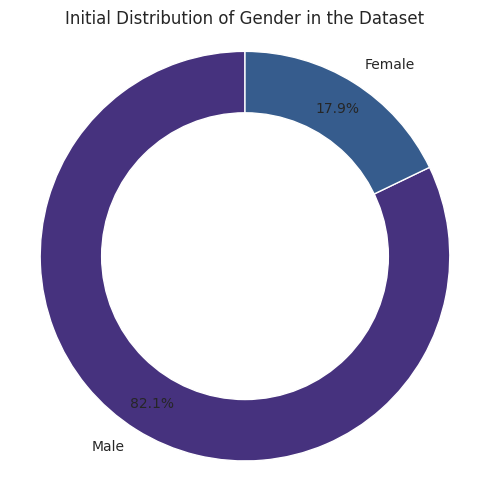

In [28]:
gender_counts = df['Gender'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, 
        pctdistance=0.85, colors=sns.color_palette('viridis'))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Initial Distribution of Gender in the Dataset')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Clinical Interpretation & Insights**

This initial donut chart immediately reveals a significant gender imbalance, with males constituting a much larger proportion of the dataset. From a clinical perspective, this imbalance is crucial to acknowledge. It implies that any direct comparison of raw counts between genders would be misleading, potentially overstating issues in the more represented group and understating them in the less represented group. This necessitates the use of proportional analyses throughout the study to ensure fair and clinically relevant comparisons, preventing biased conclusions about gender-specific mental health trends.

#### **Step 2.2: Handling Gender Imbalance and the 'Male Housewife' Anomaly**

Addressing data anomalies and imbalances is a cornerstone of robust data validation. Here, we tackle the 'Male Housewife' entry by recategorizing it to a gender-neutral 'Homemaker' term. This preserves valuable data points while correcting a potentially misleading occupational label. Furthermore, we acknowledge the overall gender distribution imbalance which we account for by proportion analyses in the subsequent steps.

In [29]:
df[(df['Gender'] == 'Male') & (df['Occupation'] == 'Housewife')].shape[0]

54735

There are 54735 data entry with a male housewife row.

In [30]:
df_cleaned = df.copy()
# This ensures the original raw data remains untouched for reference or alternative analyses.
df_cleaned['Occupation'] = df_cleaned['Occupation'].replace('Housewife', 'Homemaker')
#    we recategorize \'Housewife\' to the gender-neutral term \'Homemaker\'. This approach retains the data while
#    ensuring inclusivity and accuracy in occupational categorization.

In [31]:
df_cleaned[(df_cleaned['Gender'] == 'Male') & (df_cleaned['Occupation'] == 'Housewife')].shape[0]

0

**Clinical Interpretation & Insights**

This cleaning step demonstrates a thoughtful approach to data integrity. Recategorizing 'Housewife' to 'Homemaker' is clinically and socially sensitive, as it avoids deleting potentially valid data points that might represent non-traditional roles or simple data entry errors. From a medical perspective, preserving this data allows for a more complete understanding of the mental health landscape across all individuals, regardless of gender identity or traditional occupational labels. It also highlights the importance of standardizing categorical variables for accurate analysis.


#### **Step 2.3: Potential "Flat-lining" or "Trolling" Responses**

In large surveys, some respondents may provide low-quality data by selecting the same answer for a series of questions (flat-lining) or by entering nonsensical information (trolling). While difficult to detect exhaustively, we can look for patterns where a respondent provides identical answers across multiple, unrelated categorical questions. 

In [32]:
behavioral_cols = ['Growing_Stress', 'Changes_Habits', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness']
flat_liners = df_cleaned[behavioral_cols].apply(lambda x: x.nunique() == 1, axis=1)

print(f"Number of potential \"flat-lining\" responses: {flat_liners.sum()}")
if flat_liners.sum() > 0:
    print("\nSample of potential flat-lining entries:")
    print(df_cleaned[flat_liners][behavioral_cols].head())

Number of potential "flat-lining" responses: 0


#### **Step 2.5: Temporal Anomalies (Timestamp Issues)**

Timestamps are crucial for trend analysis. Anomalies such as future dates or suspiciously identical timestamps across many entries can invalidate temporal insights. We check for timestamps that are logically impossible (e.g., in the future).

In [33]:
current_date = pd.to_datetime('2026-03-08')
future_entries = df_cleaned[df_cleaned['Timestamp'] > current_date]

print(f"Number of entries with future timestamps: {len(future_entries)}")
if not future_entries.empty:
    print("\nSample of future timestamp entries:")
    print(future_entries[['Timestamp', 'Gender', 'Occupation']].head())


Number of entries with future timestamps: 0


Check for suspiciously identical timestamps (e.g., many entries at the exact same second)
This can indicate bulk data entry rather than individual responses. We can look at value counts for timestamps and flag those with unusually high frequencies. For example, The "Midnight Batch": If 50,000 entries all have the exact same timestamp down to the second, they were likely bulk-uploaded or scraped, not individually answered. This can skew your "Trend Analysis."

In [34]:
identical_timestamps = df_cleaned['Timestamp'].value_counts()
flagged_timestamps = identical_timestamps[identical_timestamps > 50000]

print(f"\nNumber of suspiciously identical timestamps (occurring > 50000 times): {len(flagged_timestamps)}")
if not flagged_timestamps.empty:
    print("\nSample of flagged timestamps and their counts:")
    print(flagged_timestamps.head())


Number of suspiciously identical timestamps (occurring > 50000 times): 0


#### **Step 2.6: Contradictory Treatment History**

It is clinically unusual for an individual to seek mental health treatment (treatment = 'Yes') without any reported Mental_Health_History or family_history of mental illness. While not impossible, a high prevalence of such cases might indicate misinterpretation of survey questions or data entry errors. This check helps flag such potentially contradictory entries.

In [35]:
contradictory_treatment = df_cleaned[
    (df_cleaned['treatment'] == 'Yes') &
    (df_cleaned['Mental_Health_History'] == 'No') &
    (df_cleaned['family_history'] == 'No')
]

print(f"Number of individuals reporting treatment with no mental health or family history: {len(contradictory_treatment)}")
if not contradictory_treatment.empty:
    print("\nSample of contradictory entries:")
    print(contradictory_treatment[['treatment', 'Mental_Health_History', 'family_history', 'Gender', 'Occupation']].head())

Number of individuals reporting treatment with no mental health or family history: 22467

Sample of contradictory entries:
    treatment Mental_Health_History family_history  Gender Occupation
121       Yes                    No             No  Female    Student
126       Yes                    No             No  Female    Student
135       Yes                    No             No  Female    Student
143       Yes                    No             No  Female    Student
144       Yes                    No             No  Female    Student


A significant number of individuals (22,467) reported seeking treatment (treatment = 'Yes') despite having no reported personal (Mental_Health_History = 'No') or family (family_history = 'No') history of mental illness. Dropping such a large subset (approx. 7.7% of the data) would result in significant information loss and could remove a clinically relevant subgroup.

From a medical perspective, these individuals are not necessarily data errors. They could represent:
* First-Episode Cases: Individuals experiencing their first mental health challenge.

* Preventative Care Seekers: People seeking therapy for life stressors (e.g., grief, burnout, relationship issues) who do not have a formal, diagnosed disorder.

* Stigma-Affected Respondents: Individuals who are comfortable admitting they are in treatment but may be hesitant to label themselves or their family with a "mental health history" due to social stigma.


Therefore, instead of removing them, we will stratify them. We will create a new feature, Clinical_Profile, to categorize respondents into three groups:

* New_Seeker: Those seeking treatment without a reported history.

* Chronic_Seeker: Those seeking treatment with a reported personal or family history.

* Non_Seeker: Those not currently seeking treatment.

This approach allows us to preserve the data and analyze the unique characteristics of this 'New Seeker' group in subsequent visualizations.


In [36]:
new_seeker_condition = (
    (df_cleaned['treatment'] == 'Yes') &
    (df_cleaned['Mental_Health_History'] == 'No') &
    (df_cleaned['family_history'] == 'No')
)
print(f"Number of individuals identified as 'New Seekers': {df_cleaned[new_seeker_condition].shape[0]}")
def categorize_profile(row):
    if row['treatment'] == 'Yes' and row['Mental_Health_History'] == 'No' and row['family_history'] == 'No':
        return 'New_Seeker'
    elif row['treatment'] == 'Yes':
        return 'Chronic_Seeker'
    else:
        return 'Non_Seeker'

df_cleaned['Clinical_Profile'] = df_cleaned.apply(categorize_profile, axis=1)


Number of individuals identified as 'New Seekers': 22467


**We will now visualize the distribution of these new clinical profiles**

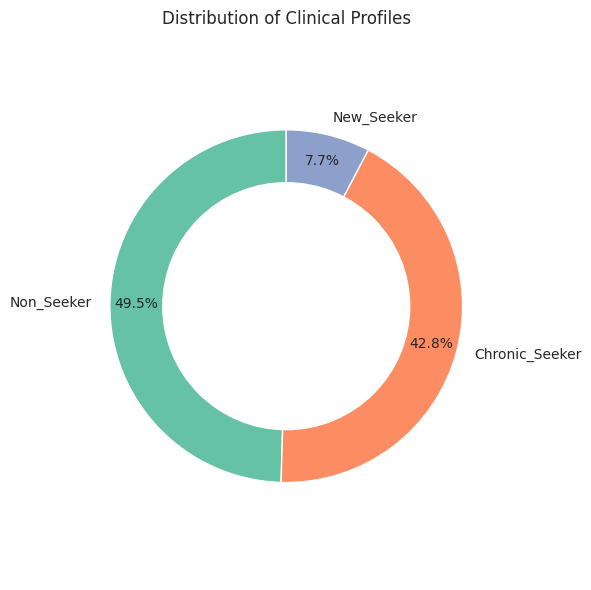

In [37]:
profile_counts = df_cleaned['Clinical_Profile'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(profile_counts, labels=profile_counts.index, autopct='%1.1f%%', startangle=90, 
        pctdistance=0.85, colors=sns.color_palette('Set2'))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Clinical Profiles')
plt.axis('equal')
plt.tight_layout()
plt.show()

**We will now visualize the proportional distribution of these profiles across genders**

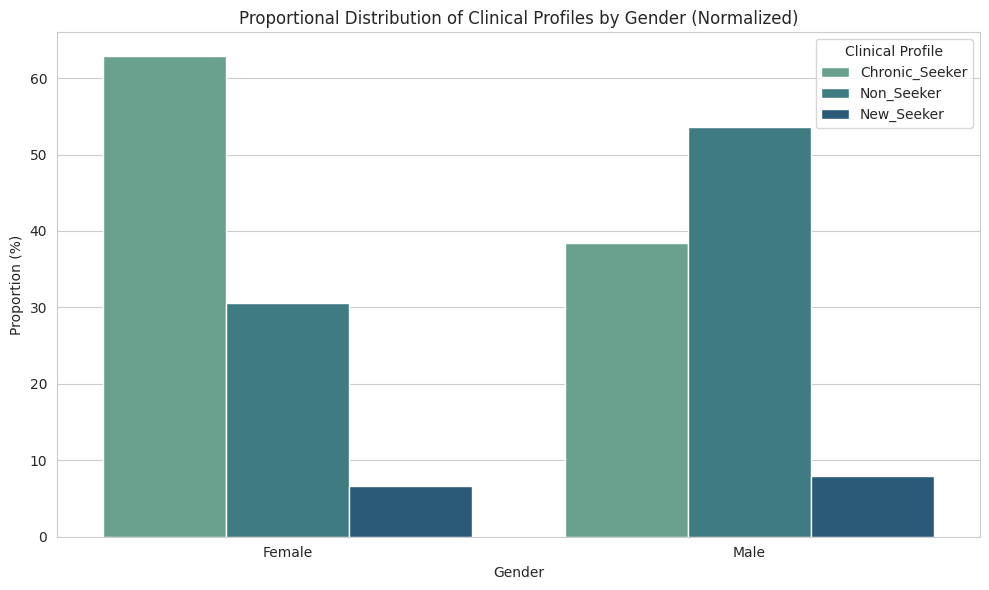

In [38]:
profile_dist = df_cleaned.groupby('Gender')['Clinical_Profile'].value_counts(normalize=True).mul(100).rename('proportion').reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='proportion', hue='Clinical_Profile', data=profile_dist, palette='crest') 
plt.title('Proportional Distribution of Clinical Profiles by Gender (Normalized)')
plt.xlabel('Gender')
plt.ylabel('Proportion (%)')
plt.legend(title='Clinical Profile')
plt.tight_layout()
plt.show()

There is a significant imbalance in treatment seeking behaviour between females and males, the females being significantly higher.

**Clinical Interpretation & Insights**

The identification of a substantial 'New Seeker' group (22,467 individuals) is a critical clinical insight. This donut chart and bar chart illustrate the distribution of these clinical profiles, both overall and across genders. The presence of 'New Seekers' suggests that a significant portion of the population may be seeking mental health support for the first time or for reasons not captured by traditional 'history' questions. This highlights a potential gap in how mental health needs are assessed and recorded. For medical personnel, this group represents an opportunity for early intervention and prevention, and their unique characteristics (e.g., stressors, coping mechanisms) warrant further investigation. The gender-specific distribution can also inform targeted outreach programs.


### **Step 3: Understanding the Landscape (Univariate & Bivariate Analysis)**

#### **Step 3.1: Demographic Distribution-Gender (After Cleaning)**

This plot displays the gender distribution after the Homemaker recategorization. While the overall imbalance might persist, this visualization confirms the application of our cleaning strategy and provides the current gender representation for subsequent proportional analyses.

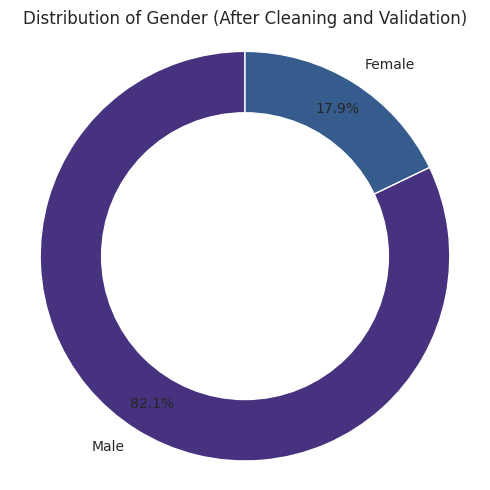

In [39]:
gender_counts_cleaned = df_cleaned['Gender'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(gender_counts_cleaned, labels=gender_counts_cleaned.index, autopct='%1.1f%%', startangle=90, 
        pctdistance=0.85, colors=sns.color_palette('viridis'))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Gender (After Cleaning and Validation)')
plt.axis('equal')
plt.tight_layout()
plt.show()

#### **Step 3.2: Treatment Prevalence (After Cleaning)**

This bar chart shows the overall prevalence of individuals seeking mental health treatment in the validated dataset. It offers a high-level view of treatment-seeking behavior, which is a key outcome variable in mental health studies.

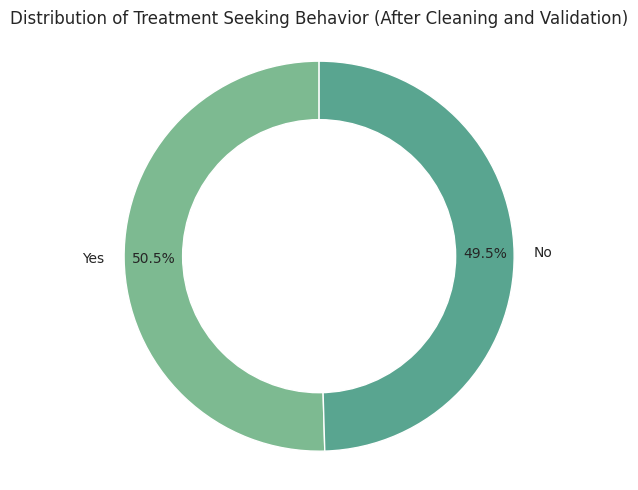

In [40]:
treatment_counts = df_cleaned['treatment'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(treatment_counts, labels=treatment_counts.index, autopct='%1.1f%%', startangle=90, 
        pctdistance=0.85, colors=sns.color_palette('crest'))

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Distribution of Treatment Seeking Behavior (After Cleaning and Validation)')
plt.axis('equal')
plt.tight_layout()
plt.show()

**Clinical Interpretation & Insights**

This donut chart provides a crucial overview of mental health treatment engagement within the studied population. The proportion of individuals seeking treatment is a direct indicator of mental health awareness, access to care, and the perceived need for professional help. From a clinical standpoint, a low prevalence of treatment seeking might suggest barriers to access, stigma, or under-diagnosis, warranting public health campaigns or improved healthcare infrastructure. Conversely, a high prevalence could indicate a greater recognition of mental health issues and a more proactive approach to care. This baseline understanding is vital for evaluating the effectiveness of mental health programs and identifying areas for improvement.


#### **Step 3.3: Demographic Distribution-Country**

This count plot visualizes the distribution of respondents across different countries in the cleaned dataset. It helps confirm that the geographical representation remains consistent and allows for identification of the primary regions contributing to the data.

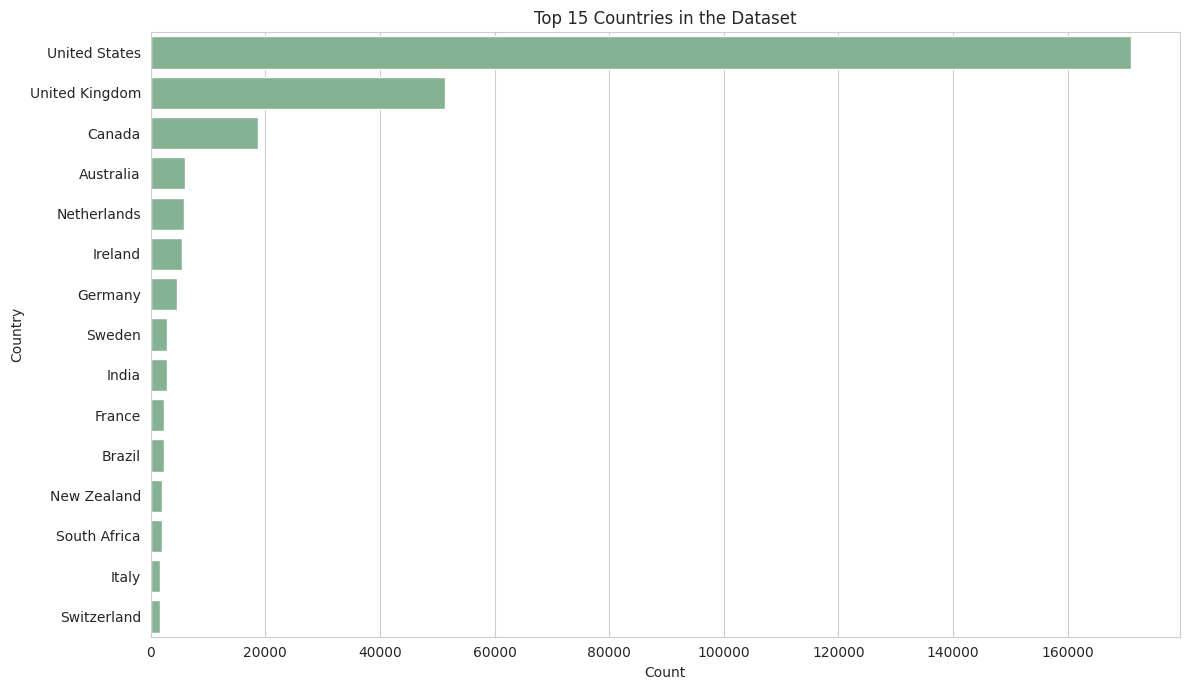

In [41]:
plt.figure(figsize=(12, 7))
sns.countplot(y='Country', data=df, order=df['Country'].value_counts().index[:15])
plt.title('Top 15 Countries in the Dataset')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**Clinical Interpretation & Insights**

Understanding the geographical distribution of respondents is crucial for interpreting the generalizability of the study's findings. If the data is heavily skewed towards a few countries, clinical insights derived might not be universally applicable and should be interpreted within the context of those specific regions. For public health planning, identifying the countries with the highest representation can indicate where mental health interventions might be most impactful or where further, more localized data collection is needed. This visualization helps set the geographical scope and potential biases of the dataset.


### **Step 4: Exploring Relationships (Multivariate Analysis with Proportions)**

This section focuses on multivariate analysis, crucial for understanding complex interactions between variables. Given the identified gender imbalance, all visualizations here use proportions or percentages to ensure fair and unbiased comparisons across different groups. This normalization is vital for drawing accurate conclusions from a demographically skewed dataset.

#### **Step 4.1 Impact Analysis: Occupation, Gender, and Growing Stress**

This analysis investigates how Growing_Stress levels (Yes, No, Maybe) are distributed across different Occupation categories, further segmented by Gender. By calculating the proportion of each stress level within each specific Occupation-Gender subgroup, we can identify the prevalence of stress for that particular demographic. This approach provides a more clinically intuitive understanding of risk within a defined group, rather than its contribution to the overall population. A Heatmap is an excellent choice here to visually represent these proportions across two categorical variables, making patterns and high-stress areas immediately apparent. The numbers in the heatmap represent the percentage of individuals within each Occupation and Gender subgroup who reported 'Yes' to Growing_Stress.

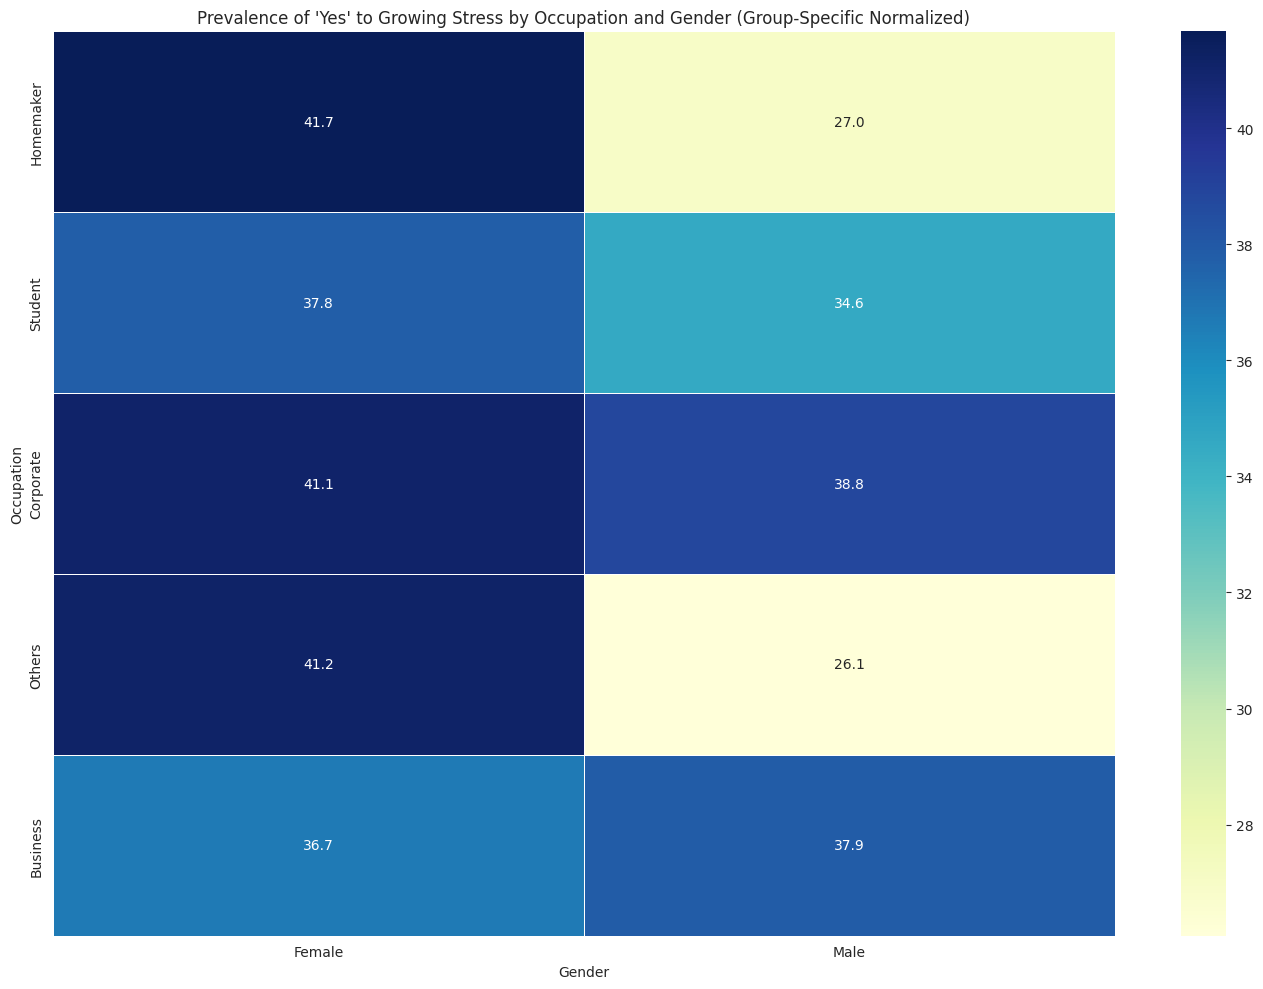

<Figure size 1600x900 with 0 Axes>

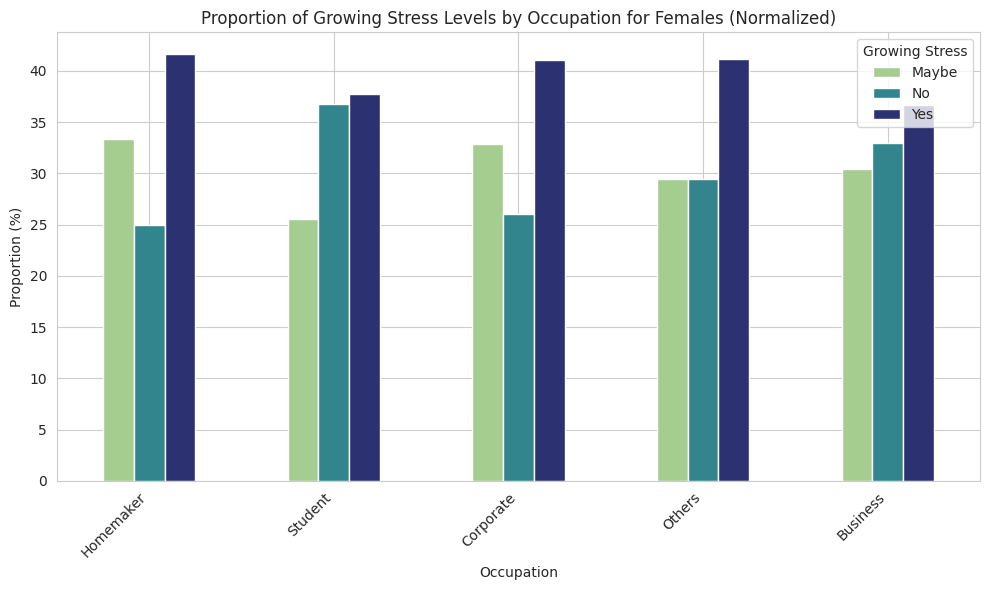

In [42]:
df_yes_stress_counts = df_cleaned[df_cleaned['Growing_Stress'] == 'Yes'].groupby(['Occupation', 'Gender']).size().unstack(fill_value=0)
df_total_counts = df_cleaned.groupby(['Occupation', 'Gender']).size().unstack(fill_value=0)
df_stress_prevalence_pivot = (df_yes_stress_counts / df_total_counts) * 100
top_occupations = df_cleaned['Occupation'].value_counts().index[:15].tolist()
if 'Homemaker' not in top_occupations and 'Homemaker' in df_stress_prevalence_pivot.index:
    top_occupations.append('Homemaker')

df_stress_prevalence_pivot = df_stress_prevalence_pivot.loc[top_occupations].dropna(how='all') # Drop rows with all NaNs if an occupation has no data for a gender

plt.figure(figsize=(14, 10))
sns.heatmap(df_stress_prevalence_pivot, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title('Prevalence of \'Yes\' to Growing Stress by Occupation and Gender (Group-Specific Normalized)')
plt.xlabel('Gender')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

df_stress_proportions_female = df_cleaned[df_cleaned['Gender'] == 'Female'].groupby(['Occupation', 'Growing_Stress']).size().unstack(fill_value=0)
df_stress_proportions_female = df_stress_proportions_female.div(df_stress_proportions_female.sum(axis=1), axis=0) * 100

plt.figure(figsize=(16, 9))
df_stress_proportions_female.loc[top_occupations].plot(kind='bar', colormap='crest')
plt.title('Proportion of Growing Stress Levels by Occupation for Females (Normalized)')
plt.xlabel('Occupation')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Growing Stress')
plt.tight_layout()
plt.show()

**Clinical Interpretation & Insights**

The heatmap reveals that certain occupations, such as 'Homemaker', 'Corporate' and 'Student', show a high prevalence of growing stress, particularly among females. This suggests that these roles may be associated with unique stressors that warrant further investigation. For medical personnel, this information can guide targeted mental health support and resources. For example, universities could be encouraged to provide more robust mental health services for students, and community programs could be developed to support homemakers. The differences in stress prevalence between genders within the same occupation also highlight the need for gender-sensitive mental health interventions.


#### **Step 4.2 Behavioral Correlations: Days_Indoors, Mood_Swings, and Coping_Struggles (Normalized)**
This visualization examines the intricate relationship between Days_Indoors, Mood_Swings, and Coping_Struggles. By plotting the proportion of individuals experiencing significant Mood_Swings (e.g., 'Yes') across different durations of Days_Indoors, further segmented by their Coping_Struggles levels, we can investigate how these behavioral factors interact. A bar chart is introduced here to visualize the distribution and density of individual responses for these categorical variables, with Coping_Struggles as a differentiating hue. This helps in understanding if prolonged indoor stays, combined with certain coping struggles, correlate with higher rates of mood swings, while showing the underlying data points.

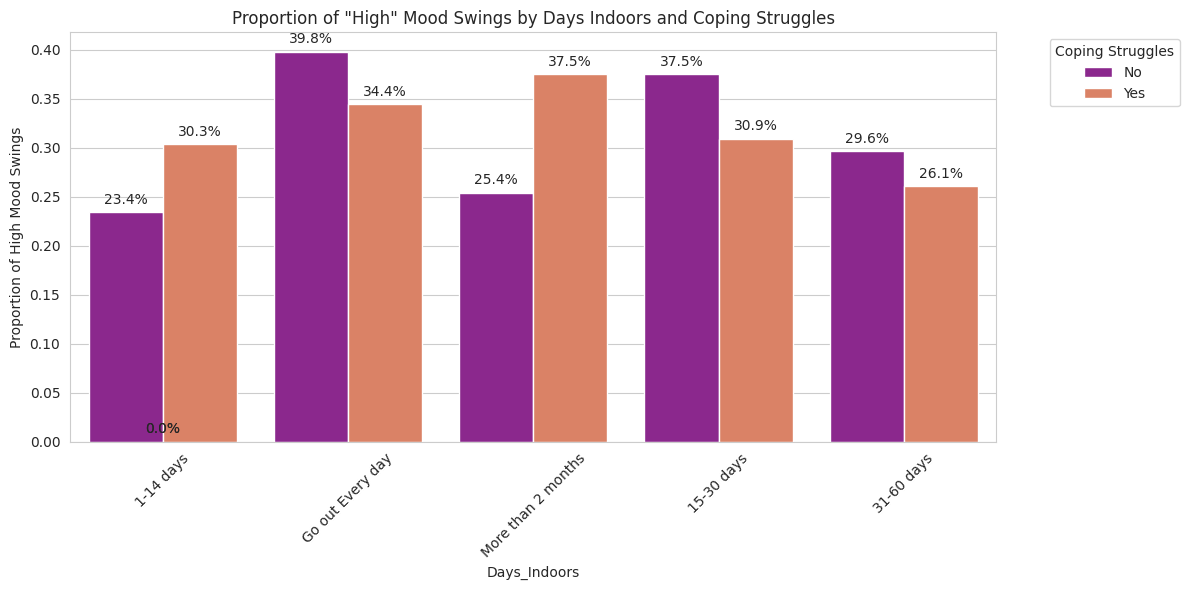

In [43]:
Mood_Swings_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Mood_Swings_Numeric'] = df['Mood_Swings'].map(Mood_Swings_mapping)
days_order = ['1-14 days', 'Go out Every day', 'More than 2 months', '15-30 days', '31-60 days']

prop_df = df.groupby(['Days_Indoors', 'Coping_Struggles'])['Mood_Swings'].apply(lambda x: (x == 'High').mean()).reset_index(name='Proportion')
plt.figure(figsize=(12, 6))
sns.barplot(data=prop_df, x='Days_Indoors', y='Proportion', hue='Coping_Struggles', order=days_order, palette='plasma')

plt.title('Proportion of "High" Mood Swings by Days Indoors and Coping Struggles')
plt.ylabel('Proportion of High Mood Swings')
plt.xticks(rotation=45)
plt.legend(title='Coping Struggles', bbox_to_anchor=(1.05, 1), loc='upper left')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()


**Clinical Interpretation & Insights**

This bar chart plot offers a view into the interplay of environmental factors (Days_Indoors), emotional states (Mood_Swings), and coping mechanisms (Coping_Struggles). From a clinical perspective, observing clusters of individuals with high mood swings and poor coping strategies, especially after prolonged indoor stays, can highlight specific risk groups. This could inform the development of targeted interventions, such as promoting outdoor activities for individuals with identified coping struggles, or providing mental health support for those in isolation. The visualization helps clinicians understand the complex behavioral patterns that contribute to mental health challenges.


#### **Step 4.3: Treatment Gap Analysis by Clinical Profile**

This analysis leverages our new Clinical_Profile feature to explore the treatment gap. Instead of just looking at Mental_Health_History, we can now compare the characteristics of New_Seeker, Chronic_Seeker, and Non_Seeker groups. For example, we can analyze how Growing_Stress levels differ across these profiles. A stacked bar Chart is introduced here to visualize the relationship between Clinical_Profile and Growing_Stress, with the size of the bars representing the count of individuals in each category. This provides a clear and engaging way to see the distribution and magnitude of each subgroup.


<Figure size 1200x700 with 0 Axes>

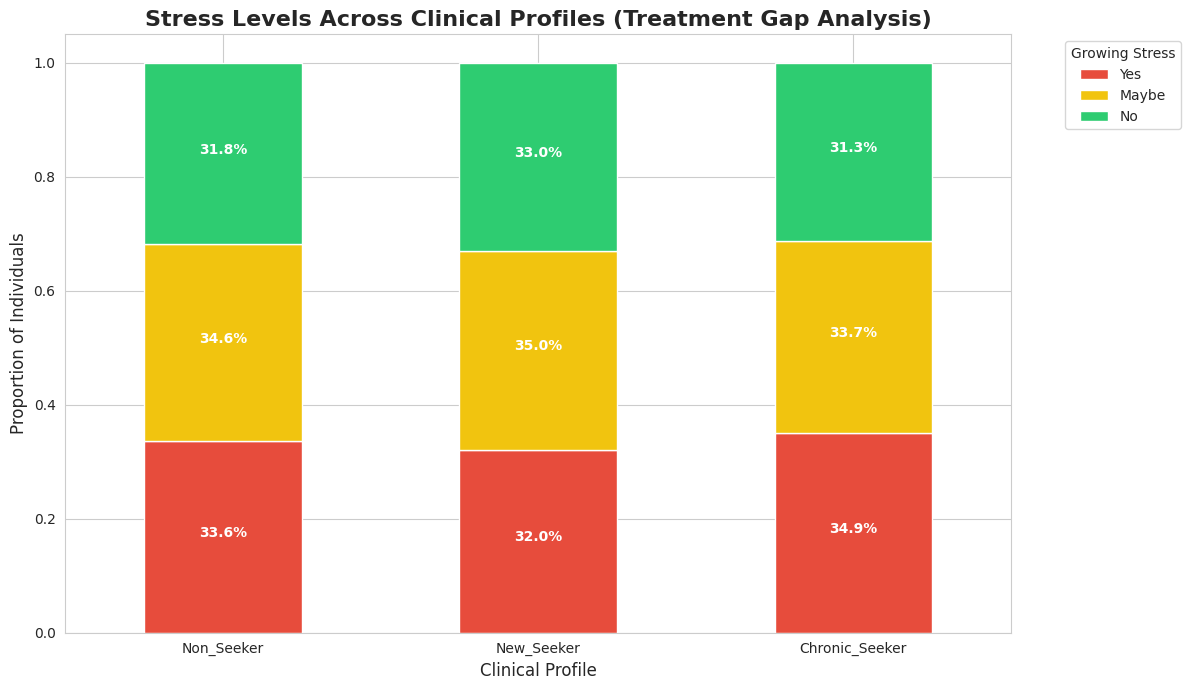

In [44]:
profile_order = ['Non_Seeker', 'New_Seeker', 'Chronic_Seeker']
stress_order = ['Yes', 'Maybe', 'No']

composition = df_cleaned.groupby('Clinical_Profile')['Growing_Stress'].value_counts(normalize=True).unstack().fillna(0)
composition = composition.reindex(index=profile_order, columns=stress_order)

plt.figure(figsize=(12, 7))
ax = composition.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#e74c3c', '#f1c40f', '#2ecc71'])

plt.title('Stress Levels Across Clinical Profiles (Treatment Gap Analysis)', fontsize=16, fontweight='bold')
plt.ylabel('Proportion of Individuals', fontsize=12)
plt.xlabel('Clinical Profile', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Growing Stress', bbox_to_anchor=(1.05, 1), loc='upper left')

for n, x in enumerate([*composition.index.values]):
    for (proportion, y_loc) in zip(composition.loc[x], composition.loc[x].cumsum()):
        if proportion > 0.05:
            plt.text(x=n, y=(y_loc - proportion) + (proportion / 2),
                     s=f'{proportion:.1%}', color="white", fontsize=10, fontweight="bold", ha="center")

plt.tight_layout()
plt.show()


**Clinical Interpretation & Insights**

This bar chart provides a powerful summary of the mental health landscape by Clinical_Profile and Growing_Stress. From a clinical perspective, it allows for a quick visual assessment of which profiles are most affected by stress and the relative size of these groups. For instance, a large bar for 'New_Seeker' with 'Yes' stress would highlight a significant population experiencing stress for the first time, indicating a need for accessible primary mental healthcare. Conversely, a large 'Chronic_Seeker' bar with 'Yes' stress would point to the ongoing burden on existing mental health services. This kind of visualization is invaluable for resource allocation, policy development, and understanding the differential needs of various patient segments.


#### **Step 4.4 Multivariate Clinical Pathway Analysis: Parallel Categories (Alluvial) Diagram**

Introduction: Mapping the Patient Journey Across Dimensions

While bivariate analyses (like heatmaps or bar charts) are excellent for seeing how two variables interact, they often fail to capture the multidimensional nature of mental health. A patient's decision to seek treatment is rarely based on a single factor; it is the culmination of their history, current stressors, and their ability to cope.

The Parallel Categories Diagram (also known as an Alluvial Plot) allows us to visualize this "flow" of individuals across multiple categorical dimensions simultaneously. By tracing the ribbons from left to right, we can identify the most common clinical pathways and detect where specific sub-populations might be falling through the cracks of the healthcare system. This visualization is particularly powerful for identifying non-linear relationships that are difficult to detect in standard statistical tables or Excel-based charts.


In [45]:
import plotly.graph_objects as go
cols = ['family_history', 'Growing_Stress', 'Coping_Struggles', 'treatment']

df_counts = df_cleaned.groupby(cols).size().reset_index(name='count')

df_counts['treatment_numeric'] = df_counts['treatment'].map({'Yes': 1, 'No': 0})

fig = go.Figure(go.Parcats(
    dimensions=[
        {'label': 'Family History', 'values': df_counts['family_history']},
        {'label': 'Growing Stress', 'values': df_counts['Growing_Stress']},
        {'label': 'Coping Struggles', 'values': df_counts['Coping_Struggles']},
        {'label': 'Treatment Seeking', 'values': df_counts['treatment']}
    ],
    counts=df_counts['count'],
    line={
        'color': df_counts['treatment_numeric'], 
        'colorscale': [[0, '#D3D3D3'], [1, '#2E8B57']], 
        'shape': 'hspline'},
    hoveron='dimension',
    hoverinfo='count+probability',
    labelfont={'size': 14, 'family': 'Arial', 'color': 'black'},
    tickfont={'size': 12}
))

fig.update_layout(
    title_text="Multivariate Clinical Pathway: History -> Stress -> Coping -> Treatment",
    width=900,
    height=600,
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.show()

**Clinical Interpretation & Significance**

The Parallel Categories Diagram provides several layers of clinical insight that are essential for medical personnel and public health researchers:

1. Identification of High-Risk Trajectories

By following the SeaGreen ribbons (those seeking treatment), we can see which combinations of factors most strongly lead to care-seeking behavior. For example, a thick ribbon flowing from family_history: Yes through Growing_Stress: Yes and Coping_Struggles: Yes indicates a classic clinical pathway where history and acute symptoms align to drive treatment.

2. Detecting the "Resilience Gap"

The Gray ribbons (those NOT seeking treatment) that pass through Growing_Stress: Yes and Coping_Struggles: Yes represent a critical clinical concern. These individuals are experiencing significant mental health challenges but are not accessing professional support. This "Resilience Gap" highlights a population that may benefit from targeted outreach or a reduction in barriers to care (e.g., cost, stigma, or accessibility).

3. The "New Seeker" Phenomenon

The diagram visually confirms the existence of "New Seekers"—individuals with no family history and no growing stress who still appear in the treatment group. Tracing their ribbons reveals whether their treatment-seeking is driven by Coping_Struggles or other factors not captured in the primary history questions. This suggests that for a significant portion of the population, mental health needs are acute or situational rather than chronic or hereditary.

4. Significance for Public Health Strategy

| Insight Type | Clinical Significance |
| --- | --- |
| **Volume Analysis** | The width of the ribbons allows for immediate prioritization of the largest sub-groups in the population. |
| **Conditional Probability** | Hovering over a category (e.g., `Growing_Stress: Yes`) shows the probability of the next state, helping clinicians predict patient outcomes based on current symptoms. |
| **Intervention Points** | By identifying where the "flow" to treatment breaks down (e.g., between `Coping_Struggles` and `treatment`), we can pinpoint exactly where to implement interventions, such as workplace mental health programs or community support groups. |




This multivariate approach ensures that our EDA is not just a collection of isolated facts, but a cohesive narrative of the mental health landscape within this dataset.



# **Conclusion: From Data Validation to Clinical Insight**
This Exploratory Data Analysis (EDA) demonstrates that mental health trends are best understood through a multidimensional clinical lens. By first performing rigorous data cleaning—including handling null values, removing duplicate rows, and standardizing timestamps into datetime format—we established a robust foundation for analysis. This validation phase was critical in addressing anomalies like "flat-lining" responses and the "Male Housewife" entry, ensuring that subsequent insights were not skewed by data entry errors. The use of the Parallel Categories Diagram then successfully mapped the complex "flow" from family history and growing stress to coping struggles and treatment-seeking behavior, revealing a critical "Resilience Gap"—a high-risk population experiencing significant stress who are not yet accessing professional care.

Ultimately, these findings underscore that clinical history alone is an insufficient predictor of a patient's needs. The emergence of the "New Seeker" group—individuals seeking care without a prior personal or family history—highlights the increasing impact of situational stressors in modern mental health. For medical personnel and public health strategists, this analysis provides a cohesive roadmap for intervention, suggesting that early support should prioritize high-stress environments and individual coping mechanisms. By moving beyond simple descriptive statistics into pattern recognition, this EDA transforms raw survey data into actionable insights for improving patient care and mental health accessibility